# Práctica 3. Herramientas de análisis de imagen de IA: SAM

#### Recuperación de los resultados de la práctica anterior

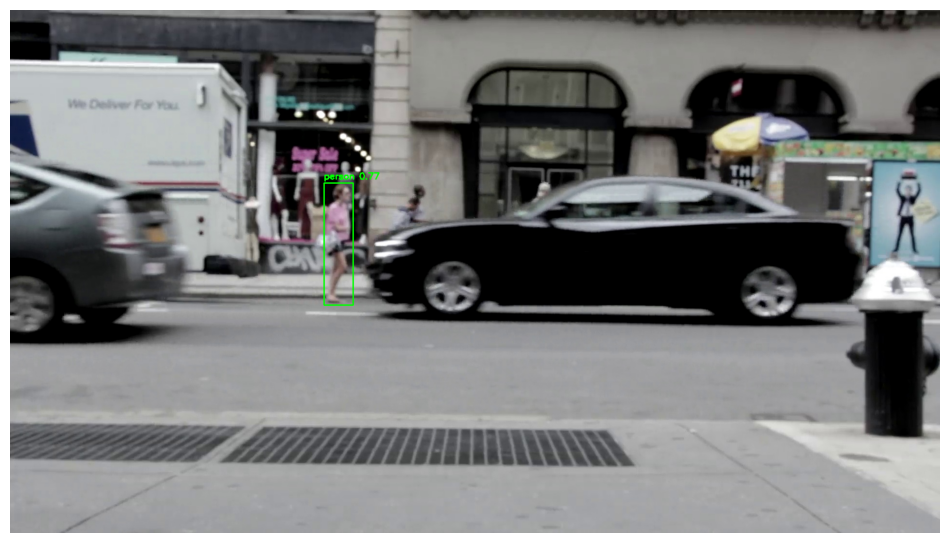

Frame cargado: images/calle_frame_90.jpg
Resultados cargados: calle_frame_90_results.json
Bounding boxes disponibles para SAM: 1


In [1]:
# Carga del frame 90 y sus resultados guardados en la celda 24

import cv2
import json
from matplotlib import pyplot as plt

frame_path = "images/calle_frame_90.jpg"
results_path = "calle_frame_90_results.json"

frame_90 = cv2.imread(frame_path)

if frame_90 is None:
    raise FileNotFoundError(f"No se pudo cargar el frame: {frame_path}")

with open(results_path, "r", encoding="utf-8") as file:
    frame_90_metadata = json.load(file)

if frame_90_metadata["image_path"] != frame_path:
    raise ValueError("El JSON no corresponde con la imagen cargada.")

frame_90_boxes = frame_90_metadata["boxes"]
frame_90_boxes_xyxy = [box["xyxy"] for box in frame_90_boxes]
frame_90_rgb = cv2.cvtColor(frame_90, cv2.COLOR_BGR2RGB)

# Visualización de las bounding boxes guardadas, sin volver a ejecutar YOLO.
frame_90_display = frame_90_rgb.copy()

for box in frame_90_boxes:
    x1, y1, x2, y2 = box["xyxy"]
    label = f"{box['class_name']} {box['confidence']:.2f}"

    cv2.rectangle(
        frame_90_display,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )
    cv2.putText(
        frame_90_display,
        label,
        (x1, max(20, y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

plt.figure(figsize=(12, 7))
plt.imshow(frame_90_display)
plt.axis("off")
plt.show()

print(f"Frame cargado: {frame_path}")
print(f"Resultados cargados: {results_path}")
print(f"Bounding boxes disponibles para SAM: {len(frame_90_boxes_xyxy)}")

## 1. SAM en imagen

#### Generación del modelo SAM

In [2]:
from ultralytics import SAM

model_sam = SAM("sam_b.pt")

#### Segmentación en una imagen

#### Segmentación sin prompts

In [4]:
# Segmentación automática del frame 90 sin prompts

import os
import cv2
import numpy as np

if "model_sam" not in globals():
    from ultralytics import SAM
    model_sam = SAM("sam_b.pt")

frame_path = "images/calle_frame_90.jpg"
cache_path = "calle_frame_90_sam_automatic_masks.npz"
frame_90_bgr = cv2.imread(frame_path)

if frame_90_bgr is None:
    raise FileNotFoundError(
        f"No se encontró {frame_path}. Ejecuta primero las últimas celdas de la práctica anterior."
    )

frame_height, frame_width = frame_90_bgr.shape[:2]
window_name = "SAM automático: A/D cambiar máscara"
cache_is_valid = False

if os.path.exists(cache_path):
    try:
        cached_data = np.load(cache_path)
        cached_masks = cached_data["masks"].astype(bool)
        cache_is_valid = cached_masks.shape[1:] == (frame_height, frame_width)
    except (KeyError, OSError, ValueError):
        cache_is_valid = False

if cache_is_valid:
    frame_90_auto_masks = cached_masks
    print("Caché automática de SAM cargada; no se repite el análisis.")
else:

    # Segmentación automática (modo "segmentar todo"): al no pasar prompts
    # (puntos, cajas o máscaras), SAM segmenta todos los objetos de la imagen.
    auto_sam_results = model_sam(frame_90_bgr, verbose=False)

    auto_sam_result = auto_sam_results[0]

    if auto_sam_result.masks is None:
        raise RuntimeError("SAM no ha generado máscaras automáticamente.")

    frame_90_auto_masks = (
        auto_sam_result.masks.data
        .detach()
        .cpu()
        .numpy()
        .astype(bool)
    )

    if frame_90_auto_masks.shape[1:] != (frame_height, frame_width):
        frame_90_auto_masks = np.stack([
            cv2.resize(
                mask.astype(np.uint8),
                (frame_width, frame_height),
                interpolation=cv2.INTER_NEAREST
            ).astype(bool)
            for mask in frame_90_auto_masks
        ])

    print("Análisis automático de SAM completado y guardado en caché.")

mask_count = len(frame_90_auto_masks)
display_mask_index = 0

screen_width, screen_height = 1600, 900
try:
    import ctypes

    screen_width = ctypes.windll.user32.GetSystemMetrics(0)
    screen_height = ctypes.windll.user32.GetSystemMetrics(1)
except (AttributeError, OSError):
    pass

max_width = max(1, screen_width - 100)
max_height = max(1, screen_height - 180)
display_scale = min(
    1.0,
    max_width / frame_width,
    max_height / frame_height
)
display_width = max(1, int(frame_width * display_scale))
display_height = max(1, int(frame_height * display_scale))


def create_display():
    if display_mask_index == 0:
        display = frame_90_bgr.copy()
        mask_text = f"Máscara: 0/{mask_count} (original)"
    else:
        selected_mask = frame_90_auto_masks[display_mask_index - 1]
        display = (frame_90_bgr * 0.25).astype(np.uint8)
        display[selected_mask] = frame_90_bgr[selected_mask]
        mask_text = f"Máscara: {display_mask_index}/{mask_count}"

    cv2.putText(
        display,
        "A: anterior | D: siguiente | Q/ESC: salir",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )
    cv2.putText(
        display,
        mask_text,
        (20, frame_height - 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    return cv2.resize(
        display,
        (display_width, display_height),
        interpolation=cv2.INTER_AREA
    )


cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, display_width, display_height)

try:
    while True:
        cv2.imshow(window_name, create_display())
        key = cv2.waitKey(30) & 0xFF

        if key in (27, ord("q")):
            break

        if key == ord("a"):
            display_mask_index = (display_mask_index - 1) % (mask_count + 1)
        elif key == ord("d"):
            display_mask_index = (display_mask_index + 1) % (mask_count + 1)
finally:
    cv2.destroyAllWindows()

np.savez_compressed(
    cache_path,
    masks=frame_90_auto_masks,
    combined_mask=np.any(frame_90_auto_masks, axis=0),
    selected_mask_index=np.asarray(display_mask_index)
)

print(f"Máscaras automáticas disponibles: {mask_count}")
print(f"Última vista seleccionada: {display_mask_index}")

Caché automática de SAM cargada; no se repite el análisis.
Máscaras automáticas disponibles: 70
Última vista seleccionada: 1


#### Segmentación con puntos como prompts

In [8]:
# Segmentación interactiva por objetos con prompts positivos y negativos

import cv2
import json
import numpy as np

if "model_sam" not in globals():
    from ultralytics import SAM
    model_sam = SAM("sam_b.pt")

frame_path = "images/calle_frame_90.jpg"
frame_bgr = cv2.imread(frame_path)

if frame_bgr is None:
    raise FileNotFoundError(
        f"No se encontró {frame_path}. Ejecuta primero las últimas celdas de la práctica anterior."
    )

frame_height, frame_width = frame_bgr.shape[:2]
window_name = "SAM: objetos y prompts"

# El objeto 0 representa siempre la imagen original sin segmentación.
objects = [{
    "positive_points": [],
    "negative_points": [],
    "masks": None,
    "selected_mask_index": 0
}]
current_object_index = 0
current_mask = None

screen_width, screen_height = 1600, 900
try:
    import ctypes

    screen_width = ctypes.windll.user32.GetSystemMetrics(0)
    screen_height = ctypes.windll.user32.GetSystemMetrics(1)
except (AttributeError, OSError):
    pass

max_width = max(1, screen_width - 100)
max_height = max(1, screen_height - 180)
display_scale = min(
    1.0,
    max_width / frame_width,
    max_height / frame_height
)
display_width = max(1, int(frame_width * display_scale))
display_height = max(1, int(frame_height * display_scale))


def selected_object():
    return objects[current_object_index]


def refresh_current_mask():
    global current_mask

    object_data = selected_object()
    masks = object_data["masks"]

    if masks is None:
        current_mask = None
        return

    selected_index = object_data["selected_mask_index"]
    current_mask = masks[selected_index]


def segment_current_object():
    object_data = selected_object()
    positive_points = object_data["positive_points"]
    negative_points = object_data["negative_points"]

    if not positive_points and not negative_points:
        object_data["masks"] = None
        object_data["selected_mask_index"] = 0
        refresh_current_mask()
        return

    prompt_points = [positive_points + negative_points]
    prompt_labels = [[
        *([1] * len(positive_points)),
        *([0] * len(negative_points))
    ]]

    '''
    --------------------------------------------------------------------------------------
    Escribe aquí el código para realizar la segmentación de la imagen de la variable
    frame_bgr. Se deben incluir como points los puntos de la variable prompt_points. Se
    deben incluir como labels los valores de la variable prompt_labels. El kwarg verbose
    debe ser False. La salida debe recogerse en la variable "sam_results".
    --------------------------------------------------------------------------------------
    '''
    sam_results = model_sam(
    frame_bgr,
    points=prompt_points,
    labels=prompt_labels,
    verbose=False
    )
    
    sam_result = sam_results[0]

    if sam_result.masks is None:
        object_data["masks"] = None
        object_data["selected_mask_index"] = 0
        refresh_current_mask()
        return

    masks = (
        sam_result.masks.data
        .detach()
        .cpu()
        .numpy()
        .astype(bool)
    )

    if masks.shape[1:] != (frame_height, frame_width):
        masks = np.stack([
            cv2.resize(
                mask.astype(np.uint8),
                (frame_width, frame_height),
                interpolation=cv2.INTER_NEAREST
            ).astype(bool)
            for mask in masks
        ])

    object_data["masks"] = masks
    object_data["selected_mask_index"] = len(masks) - 1
    refresh_current_mask()


def add_object():
    global current_object_index

    objects.append({
        "positive_points": [],
        "negative_points": [],
        "masks": None,
        "selected_mask_index": 0
    })
    current_object_index = len(objects) - 1
    refresh_current_mask()


def change_object(index):
    global current_object_index

    current_object_index = index % len(objects)
    refresh_current_mask()


def add_point(x, y, label):
    object_data = selected_object()
    point = [
        min(frame_width - 1, max(0, int(x / display_scale))),
        min(frame_height - 1, max(0, int(y / display_scale)))
    ]

    if label == 1:
        object_data["positive_points"].append(point)
    else:
        object_data["negative_points"].append(point)

    segment_current_object()


def create_display():
    object_data = selected_object()
    positive_points = object_data["positive_points"]
    negative_points = object_data["negative_points"]

    if current_mask is None:
        display = frame_bgr.copy()
        mask_text = "sin segmentar"
    else:
        display = (frame_bgr * 0.25).astype(np.uint8)
        display[current_mask] = frame_bgr[current_mask]
        mask_text = (
            f"{object_data['selected_mask_index'] + 1}/"
            f"{len(object_data['masks'])} propuestas"
        )

    for point_x, point_y in positive_points:
        cv2.circle(display, (point_x, point_y), 9, (0, 140, 255), -1)
        cv2.circle(display, (point_x, point_y), 11, (255, 255, 255), 2)

    for point_x, point_y in negative_points:
        cv2.circle(display, (point_x, point_y), 9, (255, 0, 0), -1)
        cv2.line(
            display,
            (point_x - 8, point_y - 8),
            (point_x + 8, point_y + 8),
            (255, 255, 255),
            2
        )
        cv2.line(
            display,
            (point_x + 8, point_y - 8),
            (point_x - 8, point_y + 8),
            (255, 255, 255),
            2
        )

    cv2.putText(
        display,
        "Izq: punto positivo | Der: punto negativo | A/D: cambiar objeto | T: nuevo objeto",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )
    cv2.putText(
        display,
        "R: limpiar | Q/ESC: salir",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )
    cv2.putText(
        display,
        f"Objeto {current_object_index}/{len(objects) - 1} | {mask_text}",
        (20, frame_height - 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    return cv2.resize(
        display,
        (display_width, display_height),
        interpolation=cv2.INTER_AREA
    )


def mouse_callback(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        add_point(x, y, 1)
    elif event == cv2.EVENT_RBUTTONDOWN:
        add_point(x, y, 0)


cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, display_width, display_height)
cv2.setMouseCallback(window_name, mouse_callback)

try:
    while True:
        cv2.imshow(window_name, create_display())
        key = cv2.waitKey(30) & 0xFF

        if key in (27, ord("q")):
            break
        elif key == ord("a"):
            change_object(current_object_index - 1)
        elif key == ord("d"):
            change_object(current_object_index + 1)
        elif key == ord("t"):
            add_object()
        elif key == ord("r"):
            object_data = selected_object()
            object_data["positive_points"].clear()
            object_data["negative_points"].clear()
            object_data["masks"] = None
            object_data["selected_mask_index"] = 0
            refresh_current_mask()
finally:
    cv2.destroyAllWindows()

# Guardar la última máscara y todos los prompts para reutilizarlos después.
serializable_objects = []
for object_data in objects:
    serializable_objects.append({
        "positive_points": object_data["positive_points"],
        "negative_points": object_data["negative_points"],
        "selected_mask_index": object_data["selected_mask_index"]
    })

if current_mask is not None:
    np.save("calle_frame_90_click_mask.npy", current_mask)

with open("calle_frame_90_click_objects.json", "w", encoding="utf-8") as file:
    json.dump({"objects": serializable_objects}, file, indent=4)

print(
    f"Objetos guardados: {len(objects) - 1}. "
    f"Objeto seleccionado: {current_object_index}."
)

Objetos guardados: 0. Objeto seleccionado: 0.


#### Segmentación con bounding boxes como prompts

In [11]:
# Segmentación automática de todas las personas detectadas en el frame 90 usando bounding boxes de YOLO como prompt

import cv2
import numpy as np
import json

if "model_yolo" not in globals():
    from ultralytics import YOLO
    model_yolo = YOLO("yolo26n.pt")

if "model_sam" not in globals():
    from ultralytics import SAM
    model_sam = SAM("sam_b.pt")

frame_path = "images/calle_frame_90.jpg"
cache_path = "calle_frame_90_sam_masks.npz"
frame_bgr = cv2.imread(frame_path)

if frame_bgr is None:
    raise FileNotFoundError(
        f"No se encontró {frame_path}."
    )

yolo_results = model_yolo(
    frame_bgr,
    verbose=False
)[0]

# Guardar las bounding boxes correspondientes a personas
person_boxes = []

for box in yolo_results.boxes:
    class_id = int(box.cls[0])

    # Clase 0 = person en COCO
    if class_id == 0:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        person_boxes.append([x1, y1, x2, y2])

print(f"Personas detectadas por YOLO: {len(person_boxes)}")

if person_boxes:

    sam_results = model_sam(
        frame_bgr,
        bboxes=person_boxes,
        verbose=False
    )

    sam_result_90 = sam_results[0]

    if sam_result_90.masks is not None:
        masks = (
            sam_result_90.masks.data
            .detach()
            .cpu()
            .numpy()
            .astype(bool)
        )
    else:
        masks = None
else:
    masks = None

display = frame_bgr.copy()

if masks is not None:

    for mask in masks:
        # Aumentar el brillo de las personas segmentadas para resaltarlas
        display[mask] = (
            display[mask] * 0.5 + np.array([0, 255, 255]) * 0.5
        ).astype(np.uint8)

# Dibujar las bounding boxes de YOLO
for i, box in enumerate(person_boxes):

    x1, y1, x2, y2 = box

    cv2.rectangle(
        display,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        display,
        f"Persona {i + 1}",
        (x1, max(25, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

cv2.putText(
    display,
    f"YOLO: {len(person_boxes)} personas | SAM: "
    f"{0 if masks is None else len(masks)} mascaras",
    (20, 35),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    2
)

if masks is not None:
    frame_90_sam_masks = masks
else:
    frame_90_sam_masks = np.empty(
        (0, frame_bgr.shape[0], frame_bgr.shape[1]),
        dtype=bool
    )

frame_90_sam_mask = np.any(frame_90_sam_masks, axis=0)

np.savez_compressed(
    cache_path,
    masks=frame_90_sam_masks,
    combined_mask=frame_90_sam_mask,
    boxes=np.asarray(person_boxes, dtype=np.int32)
)

with open("calle_frame_90_sam_results.json", "w", encoding="utf-8") as file:
    json.dump({
        "frame_number": 90,
        "source_image": frame_path,
        "masks_file": cache_path,
        "boxes": [[int(x) for x in box] for box in person_boxes],
        "number_of_masks": int(len(frame_90_sam_masks)),
        "mask_shape": list(frame_90_sam_masks.shape)
    }, file, indent=4)

print("Análisis de SAM completado y guardado en caché.")

window_name = "YOLO -> SAM"

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

try:
    while True:
        cv2.imshow(window_name, display)
        key = cv2.waitKey(30) & 0xFF

        if key in (27, ord("q")):
            break
finally:
    cv2.destroyAllWindows()

Personas detectadas por YOLO: 3
Análisis de SAM completado y guardado en caché.


#### Comparación entre bounding boxes de YOLO y máscaras de SAM

In [13]:
# Comparación visual de YOLO y SAM sobre el frame 90

import json
import numpy as np
import cv2

if "frame_90_rgb" not in globals():
    frame_90_bgr = cv2.imread("images/calle_frame_90.jpg")

    if frame_90_bgr is None:
        raise FileNotFoundError("No se encontró images/calle_frame_90.jpg")

    frame_90_rgb = cv2.cvtColor(frame_90_bgr, cv2.COLOR_BGR2RGB)

if "frame_90_boxes" not in globals():
    with open("calle_frame_90_results.json", "r", encoding="utf-8") as file:
        frame_90_boxes = json.load(file)["boxes"]

if "frame_90_sam_masks" not in globals():
    sam_data = np.load("calle_frame_90_sam_masks.npz")
    frame_90_sam_masks = sam_data["masks"]

frame_90_sam_mask = np.any(frame_90_sam_masks, axis=0)

# Vista YOLO: bounding boxes sobre la imagen original.
yolo_view = frame_90_rgb.copy()

for box in frame_90_boxes:
    x1, y1, x2, y2 = box["xyxy"]
    label = f"YOLO: {box['class_name']} {box['confidence']:.2f}"

    cv2.rectangle(yolo_view, (x1, y1), (x2, y2), (255, 80, 0), 5)
    cv2.putText(
        yolo_view,
        label,
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 80, 0),
        2,
        cv2.LINE_AA
    )

# Vista SAM: cada persona recibe un color distinto y semitransparente.
sam_view = frame_90_rgb.copy()
colors = [
    (0, 220, 255),
    (80, 255, 80),
    (255, 100, 255),
    (255, 220, 50),
    (100, 160, 255),
    (255, 120, 80),
    (180, 100, 255)
]

for index, mask in enumerate(frame_90_sam_masks):
    color = np.asarray(colors[index % len(colors)], dtype=np.uint8)
    sam_view[mask] = (
        0.45 * sam_view[mask] + 0.55 * color
    ).astype(np.uint8)

# Composición final: máscaras SAM y cajas YOLO en la misma imagen.
comparison_view = sam_view.copy()

for box in frame_90_boxes:
    x1, y1, x2, y2 = box["xyxy"]
    label = f"YOLO box | {box['class_name']}"

    cv2.rectangle(
        comparison_view,
        (x1, y1),
        (x2, y2),
        (255, 80, 0),
        5
    )
    cv2.putText(
        comparison_view,
        label,
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 80, 0),
        2,
        cv2.LINE_AA
    )

comparison_path = "images/calle_frame_90_yolo_sam_comparison.jpg"
cv2.imwrite(
    comparison_path,
    cv2.cvtColor(comparison_view, cv2.COLOR_RGB2BGR)
)

# Mostrar las tres vistas con OpenCV.
windows = {
    "YOLO: bounding boxes": yolo_view,
    "SAM: segmentacion pixel a pixel": sam_view,
    "Comparacion: SAM + YOLO": comparison_view
}

for window_name, view in windows.items():
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.imshow(window_name, cv2.cvtColor(view, cv2.COLOR_RGB2BGR))

cv2.waitKey(0)
cv2.destroyAllWindows()

print(f"Comparación guardada en: {comparison_path}")
print(f"Bounding boxes YOLO: {len(frame_90_boxes)}")
print(f"Máscaras SAM: {len(frame_90_sam_masks)}")

Comparación guardada en: images/calle_frame_90_yolo_sam_comparison.jpg
Bounding boxes YOLO: 1
Máscaras SAM: 3


## 2. SAM tracking en vídeo

#### SAM tracking interactivo

In [ ]:
# Segmentación interactiva de un objeto en vídeo usando SAM 2

import cv2
import numpy as np

from ultralytics.models.sam import SAM2DynamicInteractivePredictor


# ---------------------------------------------------------
# Configuración
# ---------------------------------------------------------

video_path = "images/calle.mp4"

# Frame inicial
initial_frame = 90

# Modelo SAM 2
model_path = "sam2.1_b.pt"


# ---------------------------------------------------------
# Crear predictor
# ---------------------------------------------------------

def create_predictor():

    return SAM2DynamicInteractivePredictor(
        overrides={
            "conf": 0.01,
            "task": "segment",
            "mode": "predict",
            "imgsz": 1024,
            "model": model_path,
            "save": False,
        },
        max_obj_num=1,
    )


predictor_forward = create_predictor()
predictor_backward = create_predictor()


# ---------------------------------------------------------
# Abrir vídeo
# ---------------------------------------------------------

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError(f"No se ha podido abrir el vídeo: {video_path}")

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)


# ---------------------------------------------------------
# Función para leer un frame
# ---------------------------------------------------------

def get_frame(frame_number):

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    ret, frame = cap.read()

    if not ret:
        return None

    return frame


# ---------------------------------------------------------
# Variables de interacción
# ---------------------------------------------------------

current_frame = min(initial_frame, total_frames - 1)

# Puntos introducidos por el usuario
positive_points = []
negative_points = []

# Máscara actual
current_mask = None

# Máscaras propagadas
video_masks = {}

# Estados
selection_done = False
propagated = False
playing = False

# Frame en el que se realizó la selección
selection_frame = None


# ---------------------------------------------------------
# Dibujar puntos
# ---------------------------------------------------------

def draw_points(image):

    # Puntos positivos
    for x, y in positive_points:

        cv2.circle(
            image,
            (x, y),
            7,
            (0, 255, 0),
            -1
        )

        cv2.circle(
            image,
            (x, y),
            9,
            (255, 255, 255),
            2
        )

    # Puntos negativos
    for x, y in negative_points:

        cv2.circle(
            image,
            (x, y),
            7,
            (0, 0, 255),
            -1
        )

        cv2.circle(
            image,
            (x, y),
            9,
            (255, 255, 255),
            2
        )


# ---------------------------------------------------------
# Callback del ratón
# ---------------------------------------------------------

def mouse_callback(event, x, y, flags, param):

    global positive_points
    global negative_points

    # Después de propagar ya no se pueden añadir puntos
    if propagated:
        return

    # Antes de la primera segmentación:
    # añadimos puntos normalmente.
    #
    # Después de la primera segmentación:
    # seguimos estando en el mismo frame y podemos
    # continuar añadiendo puntos para refinar.

    if event == cv2.EVENT_LBUTTONDOWN:

        positive_points.append([x, y])

    elif event == cv2.EVENT_RBUTTONDOWN:

        negative_points.append([x, y])


# ---------------------------------------------------------
# Ventana
# ---------------------------------------------------------

window_name = "SAM 2 - Segmentacion interactiva"

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

cv2.setMouseCallback(window_name, mouse_callback)


# ---------------------------------------------------------
# Bucle principal
# ---------------------------------------------------------

try:

    while True:

        frame = get_frame(current_frame)

        if frame is None:
            break

        display = frame.copy()


        # =================================================
        # MÁSCARA A MOSTRAR
        # =================================================

        mask_to_show = None

        if propagated:

            # Después de propagar, mostramos la máscara
            # correspondiente al frame actual.

            mask_to_show = video_masks.get(current_frame)

        elif current_mask is not None:

            # Antes de propagar mostramos la máscara
            # provisional del frame de selección.

            mask_to_show = current_mask


        if mask_to_show is not None:

            overlay = display.copy()

            overlay[mask_to_show] = (0, 255, 0)

            display = cv2.addWeighted(display, 0.7, overlay, 0.3, 0)


        # =================================================
        # PUNTOS
        # =================================================

        if not propagated:

            draw_points(display)


        # =================================================
        # INFORMACIÓN
        # =================================================

        cv2.putText(
            display,
            f"Frame: {current_frame + 1}/{total_frames}",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2
        )


        # -------------------------------------------------
        # Antes de la primera segmentación
        # -------------------------------------------------

        if not selection_done:

            cv2.putText(
                display,
                "IZQ: + | DER: -",
                (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (255, 255, 255),
                2
            )

            cv2.putText(
                display,
                "ENTER: segmentar",
                (20, 100),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (255, 255, 255),
                2
            )

            cv2.putText(
                display,
                "J/L: -/+1 | K/I: -/+10",
                (20, 130),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (255, 255, 255),
                2
            )


        # -------------------------------------------------
        # Después de segmentar, antes de propagar
        # -------------------------------------------------

        elif not propagated:

            cv2.putText(
                display,
                "ENTER: refinar | ESPACIO: propagar",
                (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (255, 255, 255),
                2
            )

            cv2.putText(
                display,
                "IZQ: + | DER: - | R: reiniciar",
                (20, 100),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (255, 255, 255),
                2
            )


        # -------------------------------------------------
        # Después de propagar
        # -------------------------------------------------

        else:

            cv2.putText(
                display,
                "ESPACIO: reproducir / pausar",
                (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (255, 255, 255),
                2
            )

            cv2.putText(
                display,
                "J/L: -/+1 | K/I: -/+10 | R: reiniciar",
                (20, 100),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (255, 255, 255),
                2
            )


        # -------------------------------------------------
        # Salir
        # -------------------------------------------------

        cv2.putText(
            display,
            "Q/ESC: salir",
            (20, 160),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (255, 255, 255),
            2
        )


        # =================================================
        # MOSTRAR
        # =================================================

        cv2.imshow(window_name, display)


        # Detectar cierre mediante X
        if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
            break

        key = cv2.waitKeyEx(30)
        key_low = key & 0xFF

        # =================================================
        # SALIR
        # =================================================

        if key_low in (27, ord("q")):
            break

        # =================================================
        # ANTES DE LA PRIMERA SEGMENTACIÓN
        # =================================================

        if not selection_done:

            # -------------------------------------------------
            # ENTER → primera segmentación
            # -------------------------------------------------

            if key_low in (13, 10):

                if len(positive_points) == 0:
                    print("Añade al menos un punto positivo.")
                    continue

                # Fijamos el frame de selección
                selection_frame = current_frame

                print(
                    f"Segmentando frame "
                    f"{selection_frame}..."
                )


                # ---------------------------------------------
                # IMPORTANTE:
                #
                # Todos los puntos pertenecen al MISMO objeto.
                #
                # Por eso añadimos una dimensión:
                #
                # [[punto1, punto2, punto3, ...]]
                # ---------------------------------------------

                points = [positive_points + negative_points]

                labels = [[1] * len(positive_points) + [0] * len(negative_points)]


                # ---------------------------------------------
                # SAM 2
                # ---------------------------------------------

                results = predictor_forward(
                    source=frame,
                    points=points,
                    labels=labels,
                    obj_ids=[0],
                    update_memory=True,
                )


                if (len(results) > 0 and results[0].masks is not None):

                    current_mask = (
                        results[0]
                        .masks
                        .data[0]
                        .detach()
                        .cpu()
                        .numpy()
                        .astype(bool)
                    )

                    selection_done = True

                    print("Segmentación obtenida.")

                    print("Puedes añadir más puntos y pulsar ENTER para refinar.")

                else:
                    print("No se ha obtenido ninguna máscara.")


            # -------------------------------------------------
            # J → frame anterior
            # -------------------------------------------------

            elif key_low == ord("j"):
                current_frame = max(0, current_frame - 1)

            # -------------------------------------------------
            # L → frame siguiente
            # -------------------------------------------------

            elif key_low == ord("l"):
                current_frame = min(total_frames - 1, current_frame + 1)

            # -------------------------------------------------
            # K → 10 frames atrás
            # -------------------------------------------------

            elif key_low == ord("k"):
                current_frame = max(0, current_frame - 10)

            # -------------------------------------------------
            # I → 10 frames adelante
            # -------------------------------------------------

            elif key_low == ord("i"):
                current_frame = min(total_frames - 1, current_frame + 10)

            elif key_low == ord("r"):

                positive_points = []
                negative_points = []

                current_mask = None
                video_masks = {}

                selection_done = False
                propagated = False
                playing = False

                selection_frame = None

                predictor_forward = create_predictor()
                predictor_backward = create_predictor()

                current_frame = initial_frame

                print("Selección reiniciada.")


        # =================================================
        # DESPUÉS DE LA PRIMERA SEGMENTACIÓN
        # =================================================

        elif not propagated:

            # -------------------------------------------------
            # ENTER → REFINAR
            # -------------------------------------------------

            if key_low in (13, 10):

                print("Actualizando segmentación...")

                # Volvemos a enviar TODOS los puntos
                # acumulados, que pertenecen al mismo objeto.

                points = [positive_points + negative_points]

                labels = [[1] * len(positive_points) + [0] * len(negative_points)]

                results = predictor_forward(
                    source=frame,
                    points=points,
                    labels=labels,
                    obj_ids=[0],
                    update_memory=True,
                )

                if (len(results) > 0 and results[0].masks is not None):

                    current_mask = (
                        results[0]
                        .masks
                        .data[0]
                        .detach()
                        .cpu()
                        .numpy()
                        .astype(bool)
                    )

                    print("Segmentación actualizada.")

                else:
                    print("No se ha obtenido ninguna máscara.")

            elif key_low == ord("r"):

                positive_points = []
                negative_points = []

                current_mask = None
                video_masks = {}

                selection_done = False
                propagated = False
                playing = False

                selection_frame = None

                predictor_forward = create_predictor()
                predictor_backward = create_predictor()

                current_frame = initial_frame

                print("Selección reiniciada.")

            # -------------------------------------------------
            # ESPACIO → PROPAGAR
            # -------------------------------------------------

            elif key_low == ord(" "):

                print("Comenzando propagación...")

                video_masks = {}

                # La máscara del frame inicial
                # ya la tenemos.

                video_masks[selection_frame] = current_mask

                predictor_backward(
                    source=frame,
                    points=points,
                    labels=labels,
                    obj_ids=[0],
                    update_memory=True
                )

                # -----------------------------------------
                # Propagar hacia atrás
                # -----------------------------------------

                for frame_idx in range(selection_frame - 1, -1, -1):

                    prev_frame = get_frame(frame_idx)

                    if prev_frame is None:
                        break

                    print(f"Propagando frame {frame_idx}...")
                    try:
                        results = predictor_backward(source=prev_frame)

                        if (
                            len(results) > 0
                            and results[0].masks is not None
                            and len(results[0].masks.data) > 0
                        ):

                            propagated_mask = (
                                results[0]
                                .masks
                                .data[0]
                                .detach()
                                .cpu()
                                .numpy()
                                .astype(bool)
                            )

                            video_masks[frame_idx] = propagated_mask

                        else:
                            print(f"Sin máscara en frame {frame_idx}")

                    except Exception as e:
                        print(f"ERROR propagando en frame {frame_idx}:")
                        print(type(e).__name__, e)
                        break

                # -----------------------------------------
                # Propagar hacia adelante
                # -----------------------------------------

                for frame_idx in range(selection_frame + 1, total_frames):

                    next_frame = get_frame(frame_idx)

                    if next_frame is None:
                        break

                    print(f"Propagando frame {frame_idx}...")
                    try:
                        results = predictor_forward(source=next_frame)

                        if (
                            len(results) > 0
                            and results[0].masks is not None
                            and len(results[0].masks.data) > 0
                        ):

                            propagated_mask = (
                                results[0]
                                .masks
                                .data[0]
                                .detach()
                                .cpu()
                                .numpy()
                                .astype(bool)
                            )

                            video_masks[frame_idx] = propagated_mask

                        else:
                            print(f"Sin máscara en frame {frame_idx}")

                    except Exception as e:
                        print(f"ERROR propagando en frame {frame_idx}:")
                        print(type(e).__name__, e)
                        break

                propagated = True

                current_frame = selection_frame

                print(
                    f"Propagación terminada. "
                    f"{len(video_masks)} frames segmentados."
                )

                print("Usa J/L/K/I para inspeccionar las máscaras.")

        # =================================================
        # DESPUÉS DE PROPAGAR
        # =================================================

        else:

            # -------------------------------------------------
            # ESPACIO → reproducir / pausar
            # -------------------------------------------------

            if key_low == ord(" "):
                playing = not playing

            # -------------------------------------------------
            # J → frame anterior
            # -------------------------------------------------

            elif key_low == ord("j"):

                playing = False

                current_frame = max(0, current_frame - 1)

            # -------------------------------------------------
            # L → frame siguiente
            # -------------------------------------------------

            elif key_low == ord("l"):

                playing = False

                current_frame = min(total_frames - 1, current_frame + 1)

            # -------------------------------------------------
            # K → 10 frames atrás
            # -------------------------------------------------

            elif key_low == ord("k"):

                playing = False

                current_frame = max(0, current_frame - 10)

            # -------------------------------------------------
            # I → 10 frames adelante
            # -------------------------------------------------

            elif key_low == ord("i"):

                playing = False

                current_frame = min(total_frames - 1, current_frame + 10)

            # -------------------------------------------------
            # R → reiniciar
            # -------------------------------------------------

            elif key_low == ord("r"):

                positive_points = []
                negative_points = []

                current_mask = None
                video_masks = {}

                selection_done = False
                propagated = False
                playing = False

                selection_frame = None

                predictor_forward = create_predictor()
                predictor_backward = create_predictor()

                current_frame = initial_frame

                print("Selección reiniciada.")

        # =================================================
        # REPRODUCCIÓN
        # =================================================

        if playing:

            current_frame += 1

            if (
                current_frame >= total_frames
                or current_frame not in video_masks
            ):

                current_frame = total_frames - 1

                playing = False


finally:

    cap.release()
    cv2.destroyAllWindows()


print("SAM 2 cerrado.")

Segmentando frame 119...

Ultralytics 8.4.137  Python-3.11.16 torch-2.14.0 CPU (AMD Ryzen AI 7 350 w/ Radeon 860M)
0: 1024x1024 1 0, 3776.6ms
Speed: 8.9ms preprocess, 3776.6ms inference, 6.9ms postprocess per image at shape (1, 3, 1024, 1024)
Segmentación obtenida.
Puedes añadir más puntos y pulsar ENTER para refinar.
Actualizando segmentación...

0: 1024x1024 1 0, 4023.3ms
Speed: 7.9ms preprocess, 4023.3ms inference, 9.0ms postprocess per image at shape (1, 3, 1024, 1024)
Segmentación actualizada.
Actualizando segmentación...

0: 1024x1024 1 0, 4220.0ms
Speed: 8.4ms preprocess, 4220.0ms inference, 6.3ms postprocess per image at shape (1, 3, 1024, 1024)
Segmentación actualizada.
Selección reiniciada.
Segmentando frame 115...

Ultralytics 8.4.137  Python-3.11.16 torch-2.14.0 CPU (AMD Ryzen AI 7 350 w/ Radeon 860M)
0: 1024x1024 1 0, 3820.3ms
Speed: 9.5ms preprocess, 3820.3ms inference, 6.6ms postprocess per image at shape (1, 3, 1024, 1024)
Segmentación obtenida.
Puedes añadir más puntos

#### SAM tracking a partir de las bounding boxes de YOLO

In [ ]:
# Segmentación automática de todas las personas detectadas en un vídeo usando SAM 2, a partir de YOLO

import os
import json
import cv2
import numpy as np

from ultralytics.models.sam import SAM2DynamicInteractivePredictor


# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

video_path = "images/calle.mp4"
yolo_json_path = "trajectories.json"

# Carpeta donde se guardarán las máscaras de SAM2
output_dir = "sam2_masks"
os.makedirs(output_dir, exist_ok=True)

# Modelo SAM2 utilizado
model_path = "sam2_b.pt"


# ------------------------------------------------------------
# 2. Crear predictor SAM2
# ------------------------------------------------------------

def create_predictor():
    return SAM2DynamicInteractivePredictor(
        overrides={
            "conf": 0.01,
            "task": "segment",
            "mode": "predict",
            "imgsz": 1024,
            "model": model_path,
            "save": False
        },
        max_obj_num=1
    )


print("Modelo SAM2 preparado.")


# ------------------------------------------------------------
# 3. Cargar resultados de YOLO
# ------------------------------------------------------------

with open(yolo_json_path, "r", encoding="utf-8") as f:
    trajectories = json.load(f)

object_ids = sorted(trajectories.keys(), key=int)

print(f"Personas detectadas por YOLO: {len(object_ids)}")


# ------------------------------------------------------------
# 4. Cargar vídeo
# ------------------------------------------------------------

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError(f"No se ha podido abrir el vídeo: {video_path}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Vídeo cargado: {total_frames} frames "
      f"({frame_width}x{frame_height})")


# ------------------------------------------------------------
# 5. Selección automática del mejor frame
# ------------------------------------------------------------

def select_best_frame(track_positions,
                      frame_width,
                      frame_height,
                      min_area_ratio=0.005,
                      edge_ratio=0.02,
                      temporal_window=5):
    """
    Selecciona automáticamente un frame adecuado para inicializar SAM2.

    Criterios:
        - La bounding box debe tener un tamaño mínimo.
        - No debe estar demasiado cerca de los bordes.
        - Se favorecen detecciones grandes.
        - Se favorecen frames donde la persona también aparece
          en frames cercanos.
    """

    candidates = []

    # Solo utilizamos posiciones que tengan bounding box
    valid_positions = [
        p for p in track_positions
        if p.get("box") is not None
    ]

    if len(valid_positions) == 0:
        return None

    min_area = min_area_ratio * frame_width * frame_height

    for i, position in enumerate(valid_positions):

        frame = position["frame"]
        x1, y1, x2, y2 = position["box"]

        width = x2 - x1
        height = y2 - y1
        area = width * height

        # Descartar bounding boxes demasiado pequeñas
        if area < min_area:
            continue

        # Descartar detecciones pegadas a los bordes
        if (
            x1 < edge_ratio * frame_width
            or y1 < edge_ratio * frame_height
            or x2 > (1 - edge_ratio) * frame_width
            or y2 > (1 - edge_ratio) * frame_height
        ):
            continue

        # Número de detecciones próximas temporalmente
        nearby = 0

        for other in valid_positions:
            if (
                abs(other["frame"] - frame) <= temporal_window
                and other["frame"] != frame
            ):
                nearby += 1

        # Puntuación:
        #   - mayor bbox → mejor
        #   - más detecciones cercanas → ligeramente mejor
        score = area * (1 + 0.1 * nearby)

        candidates.append((score, frame, position["box"]))

    # Si ningún frame ha pasado los filtros, utilizamos
    # simplemente la detección con mayor bounding box.
    if len(candidates) == 0:

        best = max(
            valid_positions,
            key=lambda p: (
                p["box"][2] - p["box"][0]
            ) * (
                p["box"][3] - p["box"][1]
            )
        )

        return best["frame"], best["box"]

    # Elegir el candidato con mayor puntuación
    _, best_frame, best_box = max(
        candidates,
        key=lambda x: x[0]
    )

    return best_frame, best_box


# ------------------------------------------------------------
# 6. Función para obtener una máscara de SAM2
# ------------------------------------------------------------

def get_mask_from_result(result):
    """
    Extrae la primera máscara binaria de un resultado SAM2.
    """

    if result is None or len(result) == 0:
        return None

    if result[0].masks is None:
        return None

    masks = result[0].masks.data

    if len(masks) == 0:
        return None

    mask = masks[0].cpu().numpy()

    return mask.astype(bool)


# ------------------------------------------------------------
# 7. Procesar cada persona
# ------------------------------------------------------------

for object_id in object_ids:

    print("\n" + "=" * 60)
    print(f"Procesando persona {object_id}")
    print("=" * 60)

    positions = trajectories[object_id]["positions"]

    # --------------------------------------------------------
    # Seleccionar automáticamente el frame inicial
    # --------------------------------------------------------

    best = select_best_frame(positions, frame_width, frame_height)

    if best is None:
        print(f"No se ha encontrado ningún frame válido para la persona {object_id}.")
        continue

    selection_frame, selection_box = best

    print(f"Frame inicial seleccionado: {selection_frame}")
    print(f"Bounding box: {selection_box}")

    # --------------------------------------------------------
    # Cargar el frame inicial
    # --------------------------------------------------------

    cap.set(cv2.CAP_PROP_POS_FRAMES, selection_frame)

    ret, frame = cap.read()

    if not ret:
        print(f"No se ha podido leer el frame {selection_frame}.")
        continue

    # --------------------------------------------------------
    # Crear predictores independientes
    #
    # Uno para avanzar y otro para retroceder.
    # --------------------------------------------------------

    predictor_forward = create_predictor()
    predictor_backward = create_predictor()

    # --------------------------------------------------------
    # Segmentación inicial con la bounding box de YOLO
    # --------------------------------------------------------

    bbox = [
        float(selection_box[0]),
        float(selection_box[1]),
        float(selection_box[2]),
        float(selection_box[3])
    ]

    result = predictor_forward(
        source=frame,
        bboxes=[bbox],
        obj_ids=[0],
        update_memory=True
    )

    mask = get_mask_from_result(result)

    if mask is None:
        print(f"SAM2 no ha conseguido segmentar la persona {object_id}.")
        continue

    # Diccionario:
    #
    #   frame -> máscara
    #
    video_masks = {
        selection_frame: mask
    }

    print("Segmentación inicial realizada.")

    # --------------------------------------------------------
    # Inicializar predictor hacia atrás
    #
    # Necesitamos introducir el mismo objeto en su memoria
    # antes de recorrer los frames anteriores.
    # --------------------------------------------------------

    predictor_backward(
        source=frame,
        bboxes=[bbox],
        obj_ids=[0],
        update_memory=True
    )

    # --------------------------------------------------------
    # Propagación hacia atrás
    # --------------------------------------------------------

    print("Propagando hacia atrás...")

    for frame_idx in range(selection_frame - 1, -1, -1):

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        ret, current_frame = cap.read()

        if not ret:
            continue

        result = predictor_backward(
            source=current_frame
        )

        mask = get_mask_from_result(result)

        if mask is not None:
            video_masks[frame_idx] = mask

    # --------------------------------------------------------
    # Propagación hacia delante
    # --------------------------------------------------------

    print("Propagando hacia delante...")

    for frame_idx in range(selection_frame + 1, total_frames):

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        ret, current_frame = cap.read()

        if not ret:
            continue

        result = predictor_forward(
            source=current_frame
        )

        mask = get_mask_from_result(result)

        if mask is not None:
            video_masks[frame_idx] = mask

    print(f"Propagación terminada.")
    print(f"Frames segmentados: {len(video_masks)} / {total_frames}")

    # --------------------------------------------------------
    # Guardar las máscaras
    # --------------------------------------------------------

    # Ordenar los frames
    frame_indices = np.array(
        sorted(video_masks.keys()),
        dtype=np.int32
    )

    masks = np.array(
        [video_masks[frame_idx] for frame_idx in frame_indices],
        dtype=bool
    )

    output_path = os.path.join(
        output_dir,
        f"person_{object_id}.npz"
    )

    np.savez_compressed(
        output_path,
        frames=frame_indices,
        masks=masks,
        initial_frame=selection_frame,
        initial_box=np.array(selection_box)
    )

    print(f"Máscaras guardadas en: {output_path}")


# ------------------------------------------------------------
# 8. Cerrar vídeo
# ------------------------------------------------------------

cap.release()

print("\n" + "=" * 60)
print("PROCESO TERMINADO")
print("=" * 60)
print(f"Resultados guardados en: {output_dir}/")

Modelo SAM2 preparado.
Personas detectadas por YOLO: 32
Vídeo cargado: 393 frames (1920x1080)

Procesando persona 39
Frame inicial seleccionado: 30
Bounding box: [0, 107, 607, 663]

Ultralytics 8.4.137  Python-3.11.16 torch-2.14.0 CPU (AMD Ryzen AI 7 350 w/ Radeon 860M)
0: 1024x1024 1 0, 6523.5ms
Speed: 14.8ms preprocess, 6523.5ms inference, 8.7ms postprocess per image at shape (1, 3, 1024, 1024)
Segmentación inicial realizada.

Ultralytics 8.4.137  Python-3.11.16 torch-2.14.0 CPU (AMD Ryzen AI 7 350 w/ Radeon 860M)
0: 1024x1024 1 0, 5898.3ms
Speed: 11.7ms preprocess, 5898.3ms inference, 11.7ms postprocess per image at shape (1, 3, 1024, 1024)
Propagando hacia atrás...

0: 1024x1024 1 0, 5357.3ms
Speed: 14.0ms preprocess, 5357.3ms inference, 19.8ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 1 0, 5300.5ms
Speed: 21.6ms preprocess, 5300.5ms inference, 10.6ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 1 0, 5299.2ms
Speed: 28.0ms preprocess, 5299.2

#### Comparación entre tracking YOLO y tracking SAM

In [ ]:
# Comparación entre el tracking de YOLO y el tracking de SAM2

import os
import json
import cv2
import numpy as np


# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

video_path = "images/calle.mp4"
yolo_json_path = "calle_trajectories.json"
sam2_dir = "sam2_masks"

window_name = "Comparacion YOLO vs SAM2"


# ------------------------------------------------------------
# 2. Cargar resultados de YOLO
# ------------------------------------------------------------

with open(yolo_json_path, "r", encoding="utf-8") as f:
    trajectories = json.load(f)

object_ids = sorted(trajectories.keys(), key=int)

print(f"Personas encontradas por YOLO: {len(object_ids)}")


# ------------------------------------------------------------
# 3. Preparar acceso rápido a las detecciones de YOLO
# ------------------------------------------------------------

# yolo_data[object_id][frame] = bounding box
yolo_data = {}

for object_id in object_ids:

    yolo_data[object_id] = {}

    for position in trajectories[object_id]["positions"]:

        frame = position["frame"]
        box = position["box"]

        yolo_data[object_id][frame] = box


# ------------------------------------------------------------
# 4. Cargar resultados de SAM2
# ------------------------------------------------------------

sam2_data = {}

for object_id in object_ids:

    path = os.path.join(
        sam2_dir,
        f"person_{object_id}.npz"
    )

    if not os.path.exists(path):
        print(f"No existe resultado SAM2 para persona {object_id}")
        continue

    data = np.load(path)

    frames = data["frames"]
    masks = data["masks"]

    # Diccionario:
    # sam2_data[object_id][frame] = mask
    sam2_data[object_id] = {
        int(frame): masks[i]
        for i, frame in enumerate(frames)
    }

print(f"Resultados SAM2 cargados para "
      f"{len(sam2_data)} personas.")


# ------------------------------------------------------------
# 5. Cargar vídeo
# ------------------------------------------------------------

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError(
        f"No se ha podido abrir el vídeo: {video_path}"
    )

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

frame_width = int(
    cap.get(cv2.CAP_PROP_FRAME_WIDTH)
)

frame_height = int(
    cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
)

print(
    f"Vídeo: {total_frames} frames "
    f"({frame_width}x{frame_height})"
)


# ------------------------------------------------------------
# 6. Colores para distinguir las personas
# ------------------------------------------------------------

colors = [
    (255, 80, 80),
    (80, 255, 80),
    (80, 80, 255),
    (255, 200, 50),
    (200, 80, 255),
    (50, 220, 220),
    (255, 150, 100),
    (150, 255, 100),
]


# ------------------------------------------------------------
# 7. Parámetros de reproducción
# ------------------------------------------------------------

current_frame = 0
playing = True


# ------------------------------------------------------------
# 8. Función para dibujar una máscara
# ------------------------------------------------------------

def draw_mask(image, mask, color, alpha=0.35):
    """
    Superpone una máscara binaria sobre una imagen.
    """

    if mask is None:
        return image

    # Asegurar que la máscara tiene el tamaño del frame
    if mask.shape[:2] != image.shape[:2]:

        mask = cv2.resize(
            mask.astype(np.uint8),
            (image.shape[1], image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool)

    overlay = image.copy()

    overlay[mask] = color

    image = cv2.addWeighted(
        overlay,
        alpha,
        image,
        1 - alpha,
        0
    )

    return image

cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, 1000, 600)

# ------------------------------------------------------------
# 9. Bucle de visualización
# ------------------------------------------------------------

try:

    while True:

        # ----------------------------------------------------
        # Leer frame
        # ----------------------------------------------------

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            current_frame
        )

        ret, frame = cap.read()

        if not ret:
            break

        display = frame.copy()


        # ----------------------------------------------------
        # Dibujar resultados de cada persona
        # ----------------------------------------------------

        for i, object_id in enumerate(object_ids):

            color = colors[i % len(colors)]

            yolo_box = yolo_data[object_id].get(
                current_frame
            )

            sam2_mask = None

            if object_id in sam2_data:
                sam2_mask = sam2_data[object_id].get(
                    current_frame
                )


            # ------------------------------------------------
            # Máscara SAM2
            # ------------------------------------------------

            if sam2_mask is not None:

                display = draw_mask(
                    display,
                    sam2_mask,
                    color,
                    alpha=0.35
                )


            # ------------------------------------------------
            # Bounding box YOLO
            # ------------------------------------------------

            if yolo_box is not None:

                x1, y1, x2, y2 = map(
                    int,
                    yolo_box
                )

                cv2.rectangle(
                    display,
                    (x1, y1),
                    (x2, y2),
                    color,
                    2
                )


            # ------------------------------------------------
            # Etiquetas
            # ------------------------------------------------

            if yolo_box is not None:

                x1, _, _, y2 = map(
                    int,
                    yolo_box
                )

                label_x = x1
                label_y = min(frame_height - 25, y2 + 20)

                
                # Texto del ID de YOLO
                cv2.putText(
                    display,
                    f"ID (YOLO) {object_id}",
                    (label_x, label_y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    color,
                    2,
                    cv2.LINE_AA
                )

            elif sam2_mask is not None:

                ys, xs = np.where(sam2_mask)

                if len(xs) > 0:

                    label_x = int(xs.min())
                    label_y = max(25, int(ys.min()) - 8)

                    # Texto del ID
                    cv2.putText(
                        display,
                        f"ID (SAM2) {object_id}",
                        (label_x, label_y),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        color,
                        2,
                        cv2.LINE_AA
                    )

                else:
                    continue

            else:
                continue

        # ----------------------------------------------------
        # Información superior
        # ----------------------------------------------------

        cv2.putText(
            display,
            f"Frame: {current_frame}/{total_frames - 1}",
            (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        cv2.putText(
            display,
            "YOLO: bounding boxes   |   SAM2: masks",
            (20, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        cv2.putText(
            display,
            "SPACE: play/pause   J/L: frame -/+   "
            "K/I: -/+10   Q/ESC: salir",
            (20, frame_height - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )


        # ----------------------------------------------------
        # Mostrar
        # ----------------------------------------------------

        cv2.imshow(
            window_name,
            display
        )

        # Comprobar si se ha cerrado la ventana
        if cv2.getWindowProperty(
            window_name,
            cv2.WND_PROP_VISIBLE
        ) < 1:
            break


        # ----------------------------------------------------
        # Teclado
        # ----------------------------------------------------

        key = cv2.waitKeyEx(30)


        # Q / ESC
        if key == ord("q") or key == 27:
            break


        # SPACE → play / pause
        elif key == 32:
            playing = not playing


        # J → frame anterior
        elif key == ord("j"):
            playing = False
            current_frame = max(
                0,
                current_frame - 1
            )


        # L → frame siguiente
        elif key == ord("l"):
            playing = False
            current_frame = min(
                total_frames - 1,
                current_frame + 1
            )


        # K → 10 frames atrás
        elif key == ord("k"):
            playing = False
            current_frame = max(
                0,
                current_frame - 10
            )


        # I → 10 frames adelante
        elif key == ord("i"):
            playing = False
            current_frame = min(
                total_frames - 1,
                current_frame + 10
            )


        # ----------------------------------------------------
        # Avanzar automáticamente
        # ----------------------------------------------------

        if playing:

            current_frame += 1

            if current_frame >= total_frames:
                current_frame = 0


finally:

    cap.release()
    cv2.destroyAllWindows()